<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> 
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [1]:
import io
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Astronomy 
from astroquery.sdss import SDSS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Ideal proportion for one MNRAS column
}
plt.rcParams.update(rc_params)

In [2]:
%%capture
try: 
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    import lightning.pytorch as L
except:
    !pip install torch lightning torchinfo optuna optuna-integration
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader
    import lightning.pytorch as L

In [3]:
query = f"""
SELECT TOP {500}
    p.objid, p.u, p.g, p.r, p.i, p.z, s.z as spec_z
FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid
WHERE 
    p.clean = 1 AND 
    s.class = 'GALAXY' AND 
    s.zWarning = 0 AND
    p.r > 0 AND p.u > 0 -- Filtro básico para valores anómalos
"""
resultado = SDSS.query_sql(query)
df = resultado.to_pandas()

In [4]:
df.shape, df.columns, df.head()

((500, 7),
 Index(['objid', 'u', 'g', 'r', 'i', 'z', 'spec_z'], dtype='str'),
                  objid         u         g         r         i         z  \
 0  1237646379930419437  24.37175  21.57891  19.64458  18.60767  17.95021   
 1  1237646585565413466  21.09426  18.00359  16.20469  15.18166  14.47319   
 2  1237646585567118892  23.61513  21.95656  20.14966  18.98824  18.28613   
 3  1237646586103924417  23.89194  22.37032  20.50192  19.31911  18.54503   
 4  1237646586638566303  22.47528  21.26304  20.30064  19.84324  19.52212   
 
      spec_z  
 0  0.000036  
 1  0.000239  
 2 -0.000011  
 3 -0.000054  
 4  0.000218  )

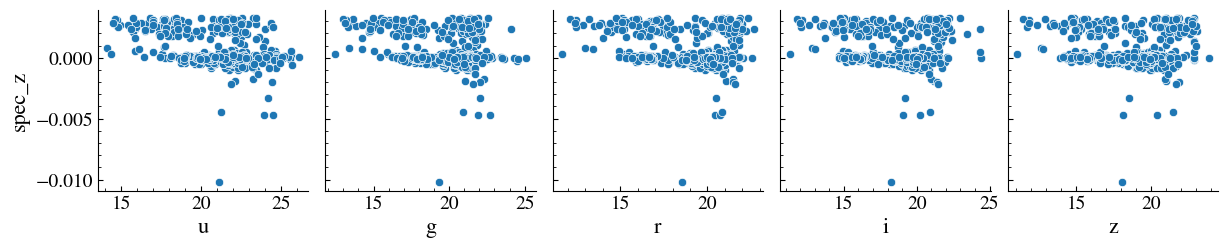

In [5]:
sns.pairplot(
    data   = df,
    x_vars = ['u', 'g', 'r', 'i', 'z'],
    y_vars = ['spec_z']
)

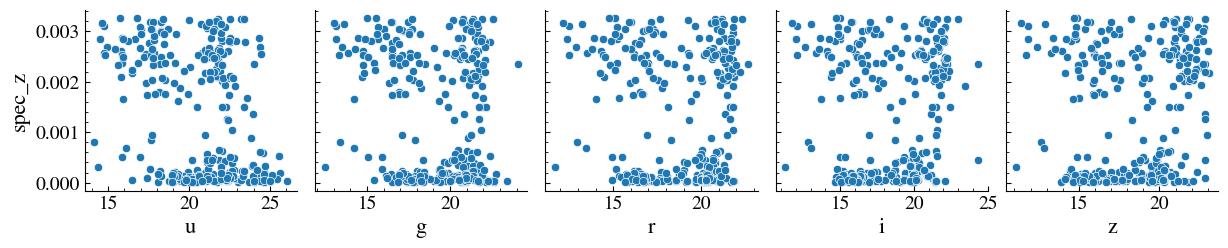

In [6]:
df = df[df.spec_z > 0]

sns.pairplot(
    data   = df,
    x_vars = ['u', 'g', 'r', 'i', 'z'],
    y_vars = ['spec_z']
)

plt.show()

# Los tres errores más comunes en PyTorch

1. **Incompatibilidad de dispositivo (Device mismatch):** PyTorch puede ejecutar operaciones en la CPU o en la GPU (CUDA), pero todos los tensores involucrados en una operación deben estar en el mismo dispositivo. Si el modelo está en la GPU y los datos llegan en CPU (o viceversa), PyTorch lanzará un error inmediatamente.

```python
# Error típico
model = model.to('cuda')
x = torch.tensor([1.0, 2.0])  # está en CPU → explota

# Solución
x = x.to('cuda')
# o de forma más robusta:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = x.to(device)
model = model.to(device)
```

2. Incompatibilidad de dimensiones (Shape mismatch): Las operaciones matriciales en PyTorch (multiplicaciones, concatenaciones, capas lineales) exigen que los tensores tengan formas compatibles. Este es probablemente el error más frecuente al diseñar una red: una capa espera una entrada de tamaño (batch, 64) pero recibe (batch, 128), o se olvida la dimensión del batch.

```python
# Error típico
linear = nn.Linear(64, 1)
x = torch.randn(32, 128)  # 128 ≠ 64 → explota

# Solución: verificar shapes antes de pasar por la red
print(x.shape)  # hábito clave para depurar
```

3. **Incompatibilidad de tipo de dato (Dtype mismatch):** PyTorch es estricto con los tipos numéricos. Lo más común es mezclar float32 y float64 (double). Por defecto, los parámetros de una red son float32, pero NumPy genera arrays en float64. Si se convierte un array de NumPy a tensor sin especificar el tipo, el resultado es float64 y la red rechaza el dato.

```python
# Error típico
y = torch.tensor(np.array([0.5, 1.2]))  # float64 por defecto en NumPy
loss = nn.MSELoss()(y_hat, y)           # y_hat es float32 → explota

# Solución
y = torch.tensor(np.array([0.5, 1.2]), dtype=torch.float32)
# o equivalentemente:
y = torch.from_numpy(np.array([0.5, 1.2])).float()
```

In [7]:
X = df[['u', 'g', 'r', 'i', 'z']].values
y = df['spec_z'].values

# Train-Val-Test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42)

print
# Estandarización
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))

X_train = scaler_X.transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

y_train = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
y_val   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# 
train_dataset = TensorDataset(torch.tensor(X_train,dtype=torch.float32), torch.tensor(y_train,dtype=torch.float32))
val_dataset   = TensorDataset(torch.tensor(X_val,dtype=torch.float32), torch.tensor(y_val,dtype=torch.float32))
test_dataset  = TensorDataset(torch.tensor(X_test,dtype=torch.float32), torch.tensor(y_test,dtype=torch.float32))


# shuffle=True en train rompe posibles correlaciones temporales/espaciales en el catálogo
batch_size   = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"DataLoaders listos. Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


DataLoaders listos. Train: 210 | Val: 45 | Test: 46


In [8]:
class GalaxyRedshift(nn.Module):
    def __init__(self, num_features=5, d_model=64, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()

        self.feature_embeddings = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(num_features)
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x):
        tokens = torch.stack([
            self.feature_embeddings[i](x[:, i].unsqueeze(-1))
            for i in range(x.size(1))
        ], dim=1)
        pooled = self.transformer_encoder(tokens).mean(dim=1)
        return self.regressor(pooled).squeeze(-1)

In [10]:
modelo = GalaxyRedshift()
modelo

GalaxyRedshift(
  (feature_embeddings): ModuleList(
    (0-4): 5 x Linear(in_features=1, out_features=64, bias=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_featu

In [11]:
device     = 'cuda' if torch.cuda.is_available() else 'cpu'
model      = GalaxyRedshift().to(device)
max_epochs = 5
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

history = {'train_loss': [], 'val_loss': []}

for epoch in range(max_epochs):

    # --- Train ---
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_hat = model(x_batch)
        loss  = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.inference_mode(): #torch.grad_no()
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_hat     = model(x_batch)
            val_loss += criterion(y_hat, y_batch).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {epoch+1}/{max_epochs}  train={train_loss:.4f}  val={val_loss:.4f}")

Epoch 1/5  train=1.0637  val=1.1544
Epoch 2/5  train=1.0279  val=1.1398
Epoch 3/5  train=1.0169  val=1.1289
Epoch 4/5  train=0.9769  val=1.1373
Epoch 5/5  train=0.9444  val=1.0997


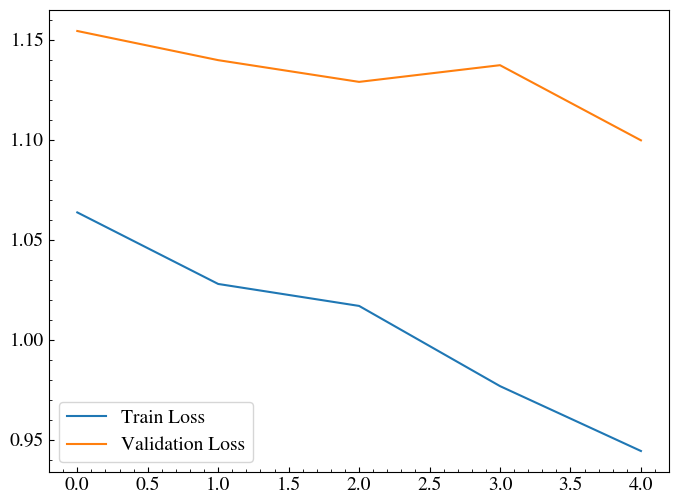

In [12]:
fig, ax = plt.subplots()

ax.plot(range(max_epochs), history['train_loss'], label='Train Loss')
ax.plot(range(max_epochs), history['val_loss'], label='Validation Loss')
ax.legend()
plt.show()

In [13]:
model.eval()
all_preds, all_targets = [], []

with torch.inference_mode():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        preds   = model(x_batch)
        all_preds.append(preds.cpu())
        all_targets.append(y_batch)

z_phot = torch.cat(all_preds).numpy()
z_spec = torch.cat(all_targets).numpy()
mse    = ((z_phot - z_spec) ** 2).mean()
print(f"MSE en Test: {mse:.4f}")

MSE en Test: 1.1221


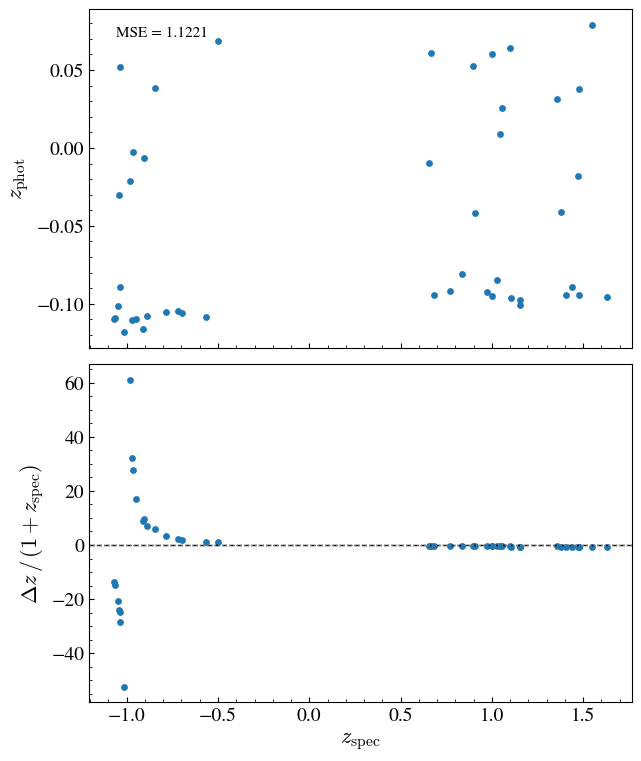

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True, gridspec_kw={'hspace': 0.05})

# Panel superior: scatter
ax1.scatter(z_spec, z_phot, s=15, alpha=1.0)
z_range = [z_spec.min(), z_spec.max()]
#ax1.plot(z_range,z_range, 'k--', lw=1, label='Ideal')
ax1.set_ylabel(r'$z_\mathrm{phot}$')
ax1.text(0.05, 0.92, f'MSE = {mse:.4f}', transform=ax1.transAxes, fontsize=11)

# Panel inferior: residuos
ax2.scatter(z_spec, (z_phot - z_spec) / (1 + z_spec), s=15, alpha=1.0)
ax2.axhline(0,     color='k',    lw=1, ls='--')
ax2.axhline( 0.15, color='gray', lw=1, ls=':')
ax2.axhline(-0.15, color='gray', lw=1, ls=':')
ax2.set_xlabel(r'$z_\mathrm{spec}$')
ax2.set_ylabel(r'$\Delta z\,/\,(1+z_\mathrm{spec})$')

plt.show()


In [16]:
class GalaxyRedshift(L.LightningModule):
    def __init__(self, num_features=5, d_model=64, nhead=4, num_layers=3, dropout=0.1, lr=1e-3):
        super().__init__()

        # Save all parameters
        self.save_hyperparameters()
        
        # Learning rate
        self.lr = lr

        # Loss criteria
        self.loss = nn.MSELoss()

        # --- Model Architecture ---
        self.feature_embeddings = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(num_features)
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model     = d_model, 
            nhead       = nhead,
            dropout     = dropout,
            batch_first = True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)

# # Primer Transformer: procesa las 5 bandas a escala d_model
#     encoder_layer_1 = nn.TransformerEncoderLayer(
#         d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
#     )
#     self.transformer_1 = nn.TransformerEncoder(encoder_layer_1, num_layers)

#     # Proyección entre los dos Transformers
#     self.bridge = nn.Sequential(
#         nn.Linear(d_model, d_model * 2),
#         nn.GELU(),
#         nn.Dropout(dropout)
#     )

#     # Segundo Transformer: trabaja en espacio más grande
#     encoder_layer_2 = nn.TransformerEncoderLayer(
#         d_model=d_model * 2, nhead=nhead, dropout=dropout, batch_first=True
#     )
#     self.transformer_2 = nn.TransformerEncoder(encoder_layer_2, num_layers)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

#         self.regressor = nn.Sequential(
#     nn.Linear(d_model, d_model),
#     nn.LayerNorm(d_model),
#     nn.GELU(),
#     nn.Dropout(dropout),
#     nn.Linear(d_model, d_model // 2),
#     nn.GELU(),
#     nn.Dropout(dropout),
#     nn.Linear(d_model // 2, d_model // 4),
#     nn.GELU(),
#     nn.Linear(d_model // 4, 1)
# )


    def forward(self, x):
        num_features = x.size(1)

        # Embeddings: x_shape -> (batch_size, num_features, d_model)
        tokens = torch.stack([
            self.feature_embeddings[i](x[:, i].unsqueeze(-1))
            for i in range(num_features)
        ], dim=1)

        # Transformer and Pooling
        transformed = self.transformer_encoder(tokens)
        pooled      = transformed.mean(dim=1)

        out = self.regressor(pooled).squeeze(-1)
        return out

    def training_step(self, batch, batch_idx):
        x, y  = batch
        y_hat = self(x)
        loss = self.loss(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss(y_hat, y)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x, y = batch
        return self(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

class HistoryCallback(L.Callback):
    def __init__(self):
        self.train_loss = []
        self.val_loss   = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics['train_loss'].item())

    def on_validation_epoch_end(self, trainer, pl_module):
        if 'val_loss' in trainer.callback_metrics:
            self.val_loss.append(trainer.callback_metrics['val_loss'].item())

In [17]:
model = GalaxyRedshift(num_features=5, d_model=64, nhead=4, num_layers=3, dropout=0.1, lr=1e-3)
model

GalaxyRedshift(
  (loss): MSELoss()
  (feature_embeddings): ModuleList(
    (0-4): 5 x Linear(in_features=1, out_features=64, bias=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    

In [18]:
from torchinfo import summary
summary(model, input_size=(1,5))

Layer (type:depth-idx)                        Output Shape              Param #
GalaxyRedshift                                [1]                       --
├─ModuleList: 1-1                             --                        --
│    └─Linear: 2-1                            [1, 64]                   128
│    └─Linear: 2-2                            [1, 64]                   128
│    └─Linear: 2-3                            [1, 64]                   128
│    └─Linear: 2-4                            [1, 64]                   128
│    └─Linear: 2-5                            [1, 64]                   128
├─TransformerEncoder: 1-2                     [1, 5, 64]                --
│    └─ModuleList: 2-6                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 5, 64]                281,152
│    │    └─TransformerEncoderLayer: 3-2      [1, 5, 64]                281,152
│    │    └─TransformerEncoderLayer: 3-3      [1, 5, 64]                281,152


In [19]:
history = HistoryCallback()
trainer = L.Trainer(max_epochs=10, accelerator='auto', devices=1, callbacks=[history], enable_progress_bar=True)

print("Iniciando el entrenamiento del Transformer...")
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Iniciando el entrenamiento del Transformer...


/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [20]:
print("Realizando inferencia en el conjunto de prueba...")
    
# Opción A: Usar el Trainer de Lightning (recomendado para grandes volúmenes)
# Retorna una lista de lotes (batches) con las predicciones
predicciones_lotes = trainer.predict(model=model, dataloaders=test_loader)

# Concatenamos todos los tensores en uno solo (1D array de predicciones)
z_phot = torch.cat(predicciones_lotes).squeeze().numpy()

# Extraemos el redshift verdadero (z_spec) del test_loader para comparar
z_spec = torch.cat([batch[1] for batch in test_loader]).numpy()

# Cálculo rápido del sesgo y error (opcional pero ilustrativo)
mse = ((z_phot - z_spec)**2).mean()
delta_z = z_phot - z_spec
#outliers = (abs(delta_z) / (1 + z_spec) > 0.15).mean() * 100

print("\n--- Resultados Astrofísicos Preliminares ---")
print(f"MSE en Test: {mse:.4f}")
#print(f"Fracción de Outliers Catastróficos: {outliers:.2f}%")
    

Realizando inferencia en el conjunto de prueba...


Predicting: |          | 0/? [00:00<?, ?it/s]


--- Resultados Astrofísicos Preliminares ---
MSE en Test: 0.6498


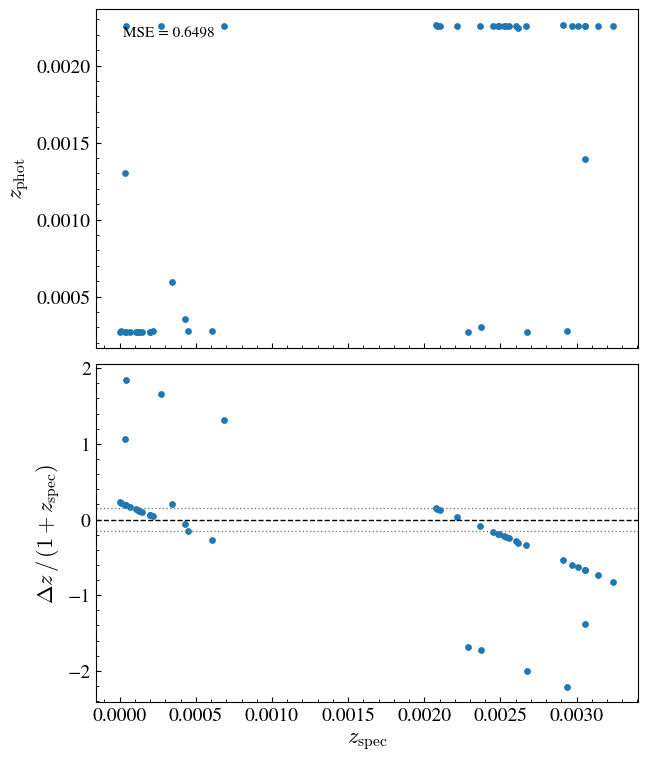

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True, gridspec_kw={'hspace': 0.05})

z_phot_real = scaler_y.inverse_transform(z_phot.reshape(-1,1)).ravel()
z_spec_real = scaler_y.inverse_transform(z_spec.reshape(-1,1)).ravel()


# Panel superior: scatter
ax1.scatter(z_spec_real, z_phot_real, s=15, alpha=1.0)
z_range = [z_spec_real.min(), z_spec_real.max()]
#ax1.plot(z_range,z_range, 'k--', lw=1, label='Ideal')
ax1.set_ylabel(r'$z_\mathrm{phot}$')
ax1.text(0.05, 0.92, f'MSE = {mse:.4f}', transform=ax1.transAxes, fontsize=11)

# Panel inferior: residuos
ax2.scatter(z_spec_real, delta_z / (1 + z_spec_real), s=15, alpha=1.0)
ax2.axhline(0,     color='k',    lw=1, ls='--')
ax2.axhline( 0.15, color='gray', lw=1, ls=':')
ax2.axhline(-0.15, color='gray', lw=1, ls=':')
ax2.set_xlabel(r'$z_\mathrm{spec}$')
ax2.set_ylabel(r'$\Delta z\,/\,(1+z_\mathrm{spec})$')

plt.show()


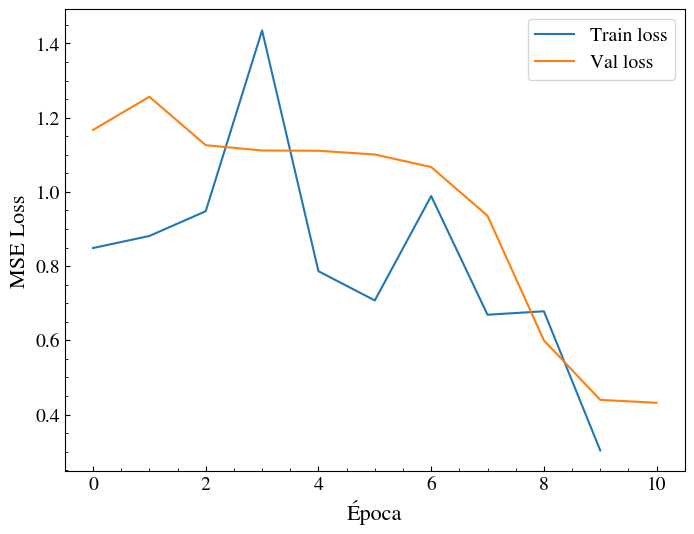

In [22]:
fig, ax = plt.subplots()
ax.plot(history.train_loss, label='Train loss')
ax.plot(history.val_loss,   label='Val loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.show()

In [23]:
import optuna
from optuna.integration import PyTorchLightningPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [24]:
def objective(trial):
    # Espacio de búsqueda
    d_model    = trial.suggest_categorical('d_model',    [32, 64, 128])
    nhead      = trial.suggest_categorical('nhead',      [h for h in [2, 4, 8] if d_model % h == 0])
    num_layers = trial.suggest_int(        'num_layers', 1, 5)
    dropout    = trial.suggest_float(      'dropout',    0.0, 0.4)
    lr         = trial.suggest_float(      'lr',         1e-4, 1e-2, log=True)

    model = GalaxyRedshift(
        num_features=5,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dropout=dropout,
        lr=lr
    )

    trainer = L.Trainer(
        max_epochs=5,
        accelerator='auto',
        devices=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        callbacks=[PyTorchLightningPruningCallback(trial, monitor='val_loss')]
    )

    trainer.fit(model, train_loader, val_loader)

    return trainer.callback_metrics['val_loss'].item()

In [25]:
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
study.optimize(objective, n_trials=50, timeout=600)  # 50 trials o 10 min

print(f"\nMejor val_loss : {study.best_value:.6f}")
print(f"Mejores params : {study.best_params}")

/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/jurados/AS4501_Astroinformatic/Auxiliar/checkpoints exists and is not empty.
/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



Mejor val_loss : 0.504989
Mejores params : {'d_model': 64, 'nhead': 4, 'num_layers': 1, 'dropout': 0.0682972520793548, 'lr': 0.0026775634215680045}


In [26]:
best = study.best_params

history = HistoryCallback()
model   = GalaxyRedshift(
    num_features=5,
    d_model    = best['d_model'],
    nhead      = best['nhead'],
    num_layers = best['num_layers'],
    dropout    = best['dropout'],
    lr         = best['lr']
)

trainer = L.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[history],
    enable_progress_bar=True
)
trainer.fit(model, train_loader, val_loader)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/tmp/ipykernel_83561/1445200797.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


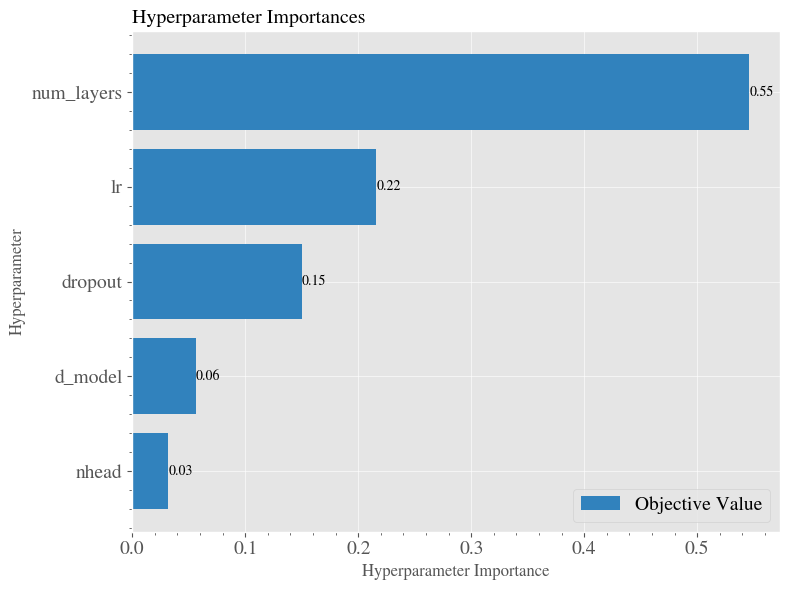

/tmp/ipykernel_83561/1445200797.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


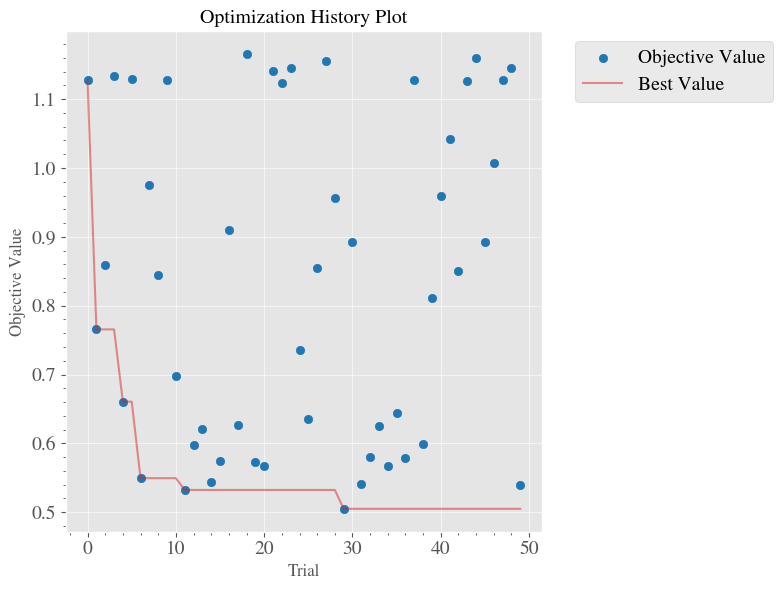

In [27]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()

optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.show()


In [28]:
print("Realizando inferencia en el conjunto de prueba...")
    
# Opción A: Usar el Trainer de Lightning (recomendado para grandes volúmenes)
# Retorna una lista de lotes (batches) con las predicciones
predicciones_lotes = trainer.predict(model=model, dataloaders=test_loader)

# Concatenamos todos los tensores en uno solo (1D array de predicciones)
z_phot = torch.cat(predicciones_lotes).squeeze().numpy()

# Extraemos el redshift verdadero (z_spec) del test_loader para comparar
z_spec = torch.cat([batch[1] for batch in test_loader]).numpy()

# Cálculo rápido del sesgo y error (opcional pero ilustrativo)
mse = ((z_phot - z_spec)**2).mean()
delta_z = z_phot - z_spec
#outliers = (abs(delta_z) / (1 + z_spec) > 0.15).mean() * 100

print("\n--- Resultados Astrofísicos Preliminares ---")
print(f"MSE en Test: {mse:.4f}")
#print(f"Fracción de Outliers Catastróficos: {outliers:.2f}%")
    

Realizando inferencia en el conjunto de prueba...


/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]


--- Resultados Astrofísicos Preliminares ---
MSE en Test: 0.6441


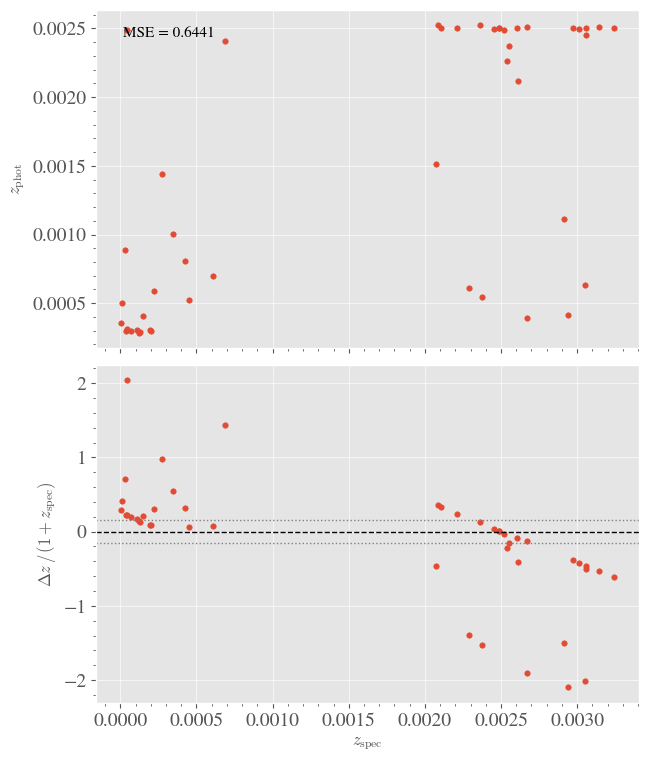

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True, gridspec_kw={'hspace': 0.05})

# Panel superior: scatter
z_phot_real = scaler_y.inverse_transform(z_phot.reshape(-1,1)).ravel()
z_spec_real = scaler_y.inverse_transform(z_spec.reshape(-1,1)).ravel()

ax1.scatter(z_spec_real, z_phot_real, s=15, alpha=1.0)
z_range = [z_spec_real.min(), z_spec_real.max()]
#ax1.plot(z_range,z_range, 'k--', lw=1, label='Ideal')
ax1.set_ylabel(r'$z_\mathrm{phot}$')
ax1.text(0.05, 0.92, f'MSE = {mse:.4f}', transform=ax1.transAxes, fontsize=11)

# Panel inferior: residuos
ax2.scatter(z_spec_real, delta_z / (1 + z_spec_real), s=15, alpha=1.0)
ax2.axhline(0,     color='k',    lw=1, ls='--')
ax2.axhline( 0.15, color='gray', lw=1, ls=':')
ax2.axhline(-0.15, color='gray', lw=1, ls=':')
ax2.set_xlabel(r'$z_\mathrm{spec}$')
ax2.set_ylabel(r'$\Delta z\,/\,(1+z_\mathrm{spec})$')

plt.show()


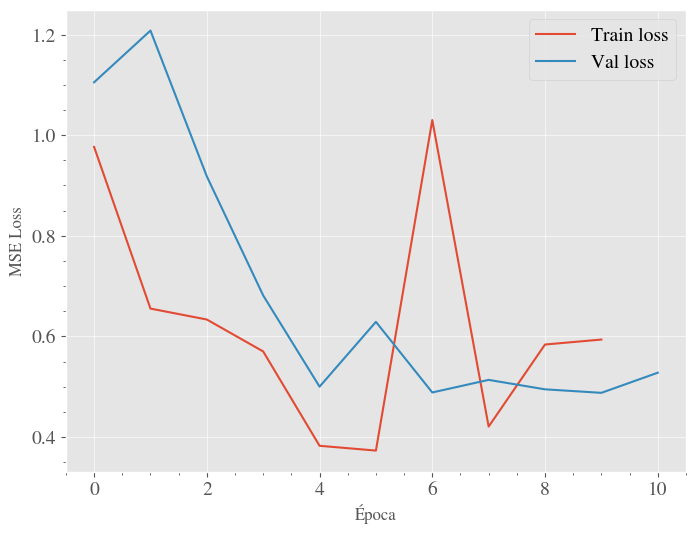

In [30]:
fig, ax = plt.subplots()
ax.plot(history.train_loss, label='Train loss')
ax.plot(history.val_loss,   label='Val loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.show()